## Explore the Distribution


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import dotenv_values
from urllib.parse import quote_plus
from scipy import stats
import numpy as np


# ---- Load .env ----
config = dotenv_values()
pg_user = config['POSTGRES_USER']
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = quote_plus(config['POSTGRES_PASS'])

# ---- Create Engine ----
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

pg_user

python-dotenv could not parse statement starting at line 1


'nicolebrueggmann'

In [8]:
query = f"""
SELECT *
FROM {pg_schema}.mart_daily_flights_weather
WHERE flight_date BETWEEN '2024-09-16' AND '2024-10-06'
ORDER BY airport, flight_date
"""
df_flights_daily = pd.read_sql(query, engine)

In [11]:
df_flights_daily.head(2)

,airport,airport_name,city,country,flight_date,dep_scheduled,dep_not_cancelled,dep_cancelled,dep_diverted,dep_early_flight,...,cancel_rate,divert_rate,dep_delayed_rate,arr_delayed_rate,max_temp_c,min_temp_c,precipitation_mm,avg_wind_direction,avg_wind_speed_kmh,avg_pressure_hpa
0,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-16,1029,1029,0,3,695,...,0.0,0.19,10.11,9.71,28.3,19.4,0.0,0,18.7,1017.2
1,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,2024-09-17,923,923,0,2,657,...,0.0,0.11,8.02,7.60,28.9,16.7,0.0,0,15.8,1014.0


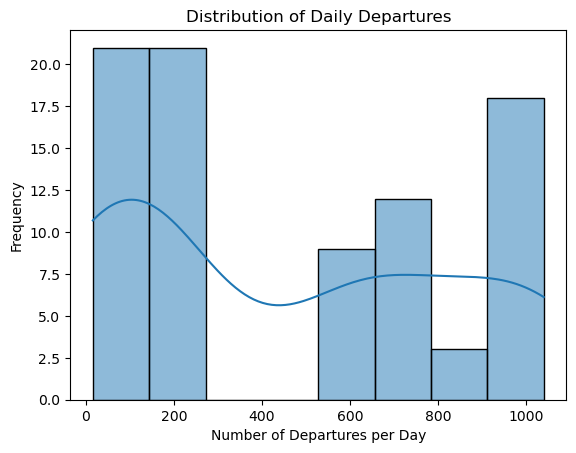

In [ ]:


sns.histplot(df_flights_daily['dep_scheduled'], kde=True)

plt.title("Distribution of Daily Departures")
plt.xlabel("Number of Departures per Day")
plt.ylabel("Frequency")

plt.show()

In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df_flights_daily['flight_date'] = pd.to_datetime(df_flights_daily['flight_date'])

helene = df_flights_daily[
    (df_flights_daily['flight_date'] >= '2024-09-24') &
    (df_flights_daily['flight_date'] <= '2024-09-29')
]['dep_delayed_rate']

normal = df_flights_daily[
    ~((df_flights_daily['flight_date'] >= '2024-09-24') &
      (df_flights_daily['flight_date'] <= '2024-09-29'))
]['dep_delayed_rate']

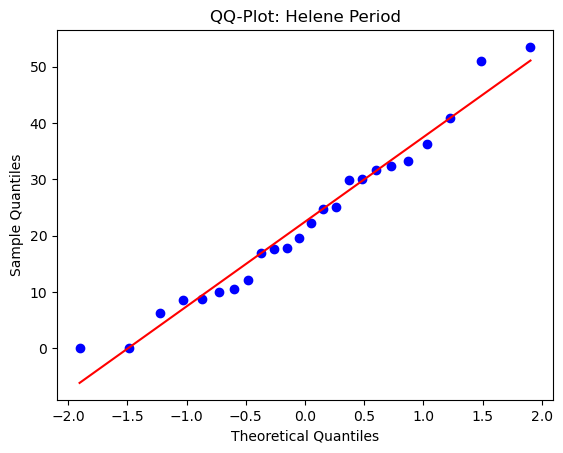

In [28]:
# QQ-Plot for Helene period
stats.probplot(helene, dist="norm", plot=plt)
plt.title("QQ-Plot: Helene Period")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.savefig("QQ-Plot_helene_period_24_29_09_2024.png", dpi=300, bbox_inches="tight")
plt.show()

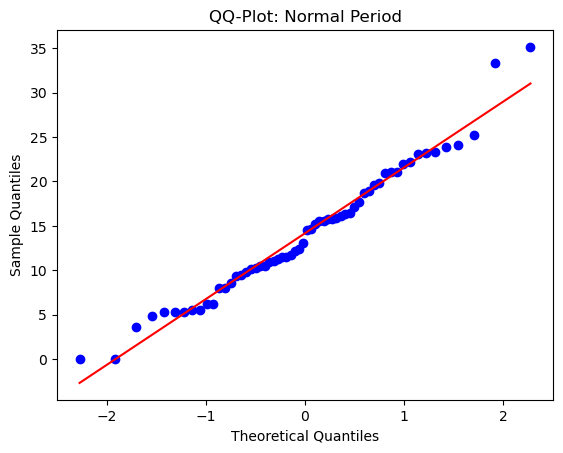

In [27]:
# QQ-Plot for Normal period
stats.probplot(normal, dist="norm", plot=plt)
plt.title("QQ-Plot: Normal Period")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.savefig("QQ-Plot_normal_flights.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
shapiro_helene = stats.shapiro(helene)
shapiro_normal = stats.shapiro(normal)

print("Helene Shapiro p:", shapiro_helene.pvalue)
print("Normal Shapiro p:", shapiro_normal.pvalue)

Helene Shapiro p: 0.5209711524797005
Normal Shapiro p: 0.21925931971715337


In [ ]:
# Coinfedencial Interval helene

mean_helene = np.mean(helene)
sem_helene = stats.sem(helene)  # Standard Error

ci_helene = stats.t.interval(
    0.95,
    len(helene)-1,
    loc=mean_helene,
    scale=sem_helene
)

print("Helene Mean:", mean_helene)
print("95% CI Helene:", ci_helene)

Helene Mean: 22.467083333333335
95% CI Helene: (np.float64(16.314675750010007), np.float64(28.619490916656662))


In [26]:
# Coindfedencial interval normal

mean_normal = np.mean(normal)
sem_normal = stats.sem(normal)

ci_normal = stats.t.interval(
    0.95,
    len(normal)-1,
    loc=mean_normal,
    scale=sem_normal
)

print("Normal Mean:", mean_normal)
print("95% CI Normal:", ci_normal)

Normal Mean: 14.166
95% CI Normal: (np.float64(12.269199405495957), np.float64(16.062800594504044))


In [29]:
shapiro_helene = stats.shapiro(helene)
shapiro_normal = stats.shapiro(normal)

print("Helene Shapiro p:", shapiro_helene.pvalue)
print("Normal Shapiro p:", shapiro_normal.pvalue)

Helene Shapiro p: 0.5209711524797005
Normal Shapiro p: 0.21925931971715337
